### RaschPy bivector MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the bivector parameterisation, each rater's severity is an additive combination of a per-item leniency effect and a per-threshold consistency effect, allowing rater behaviour to vary systematically across the latent continuum without the full item x threshold flexibility (and parameter cost) of the matrix model. It functions as rater-as-RSM, as opposed to the matrix formulation, which functions as rater-as-PCM.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Bivector(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_96399/1630473047.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Bivector(no_of_items=12, no_of_persons=200, no_of_facet_elements=8,
                           item_facet_range=1, threshold_facet_range=1, max_score=5, missing=0, seed=999)
sim.responses.to_csv('mfrm_bivector_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_bivector_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     1.0     3.0     3.0     3.0     3.0     3.0     3.0   
        Person_2     1.0     1.0     3.0     1.0     1.0     3.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     4.0     4.0      4.0      3.0      2.0  
        Person_2     3.0     4.0      3.0      2.0      2.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the bivector parameterisation (a per-item leniency effect plus a per-threshold consistency effect for each rater). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_bivector()

CPU times: user 7.57 ms, sys: 391 μs, total: 7.96 ms
Wall time: 7.92 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1    1.033412
Item_2    0.261198
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


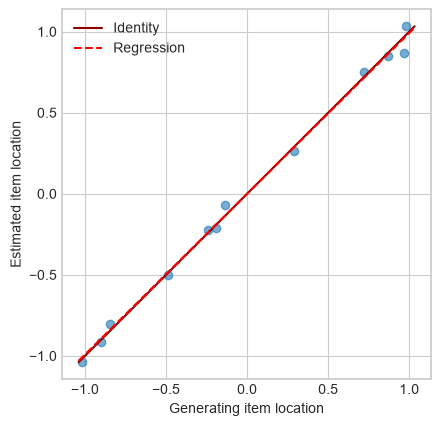

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 0.993
item location regression coefficient:            0.992
item location RMSE:                              0.042


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_bivector_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_bivector(full=True)
mfrm.item_stats_bivector.to_csv('mfrm_bivector_item_stats.csv')

CPU times: user 6.27 s, sys: 111 ms, total: 6.38 s
Wall time: 6.39 s


Check the item statistics table

In [14]:
mfrm.item_stats_bivector

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,1.033,0.043,0.950,1.118,1600,0.430,0.917,-2.417,0.912,-2.561,0.690,0.677
Item_2,0.261,0.042,0.182,0.342,1600,0.503,0.954,-1.323,0.933,-1.939,0.666,0.661
Item_3,-0.499,0.046,-0.584,-0.406,1600,0.572,0.967,-0.933,0.952,-1.381,0.651,0.649
Item_4,0.753,0.052,0.658,0.865,1600,0.451,0.989,-0.309,0.971,-0.815,0.677,0.675
Item_5,0.867,0.045,0.790,0.965,1600,0.438,0.980,-0.563,0.978,-0.627,0.687,0.683
Item_6,-0.071,0.038,-0.150,-0.001,1600,0.536,0.955,-1.266,0.939,-1.750,0.664,0.650
Item_7,-0.211,0.040,-0.296,-0.133,1600,0.541,1.036,1.008,1.035,0.995,0.665,0.652
Item_8,-1.039,0.041,-1.111,-0.957,1600,0.613,1.025,0.707,1.023,0.670,0.636,0.631
Item_9,-0.806,0.046,-0.891,-0.722,1600,0.596,0.981,-0.521,0.960,-1.144,0.641,0.638
Item_10,-0.225,0.044,-0.317,-0.145,1600,0.547,0.975,-0.703,0.979,-0.577,0.655,0.650


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_bivector(full=True)
mfrm.threshold_stats_bivector.to_csv('mfrm_bivector_threshold_stats.csv')

CPU times: user 109 ms, sys: 1.88 ms, total: 111 ms
Wall time: 111 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_bivector

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.223,0.068,-4.291,-4.038,0.928,-1.976,0.946,-0.703,1.055,0.384,0.374
Threshold 2,-1.415,0.042,-1.495,-1.328,1.000,-0.037,1.007,0.394,0.999,0.694,0.684
Threshold 3,-1.181,0.036,-1.249,-1.113,0.982,-1.621,0.969,-1.435,1.029,0.902,0.872
Threshold 4,2.378,0.038,2.293,2.435,0.982,-1.311,0.989,-0.382,1.018,0.771,0.756
Threshold 5,4.441,0.091,4.195,4.565,0.902,-1.806,0.848,-1.508,1.057,0.159,0.192


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

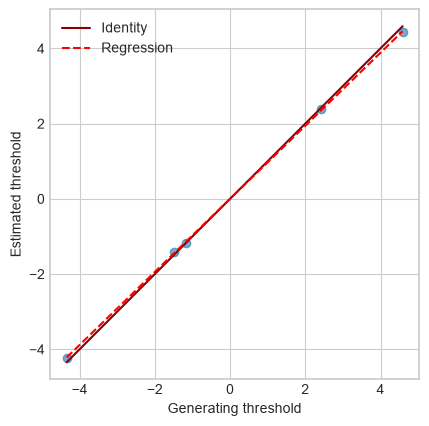

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.971
threshold regression coefficient:            0.971
threshold RMSE:                              0.097


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_bivector_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file. `rater_stats_df_bivector` reports per-item marginal severities, then per-threshold marginal severities, plus overall fit statistics for each rater.

In [18]:
%%time
mfrm.rater_stats_df_bivector()
mfrm.rater_stats_bivector.to_csv('mfrm_bivector_rater_stats.csv')

CPU times: user 313 ms, sys: 8.16 ms, total: 321 ms
Wall time: 321 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_bivector

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.413  0.122    0.427  0.147   -0.018  0.172    0.348  0.145   
Rater_2    0.138  0.135   -0.058  0.125   -0.098  0.215   -0.394  0.135   
Rater_3   -0.039  0.127    0.075  0.143    0.027  0.229   -0.287  0.130   
Rater_4    0.322  0.108    0.239  0.114    0.086  0.197    0.333  0.111   
Rater_5   -0.412  0.131   -0.189  0.139   -0.169  0.202   -0.268  0.126   
Rater_6    0.097  0.131    0.165  0.153   -0.006  0.225    0.035  0.122   
Rater_7   -0.438  0.130   -0.720  0.092   -0.116  0.215   -0.016  0.135   
Rater_8   -0.080  0.156    0.061  0.118    0.294  0.246    0.249  0.122   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1    0.127  0.118  ...       0.078       0.266  0.066      -0.074   
Rater_2   -0.119  0.126  ...       0.100      -0.264  0.081      -0.214   
Rater_3   -0.046  0.122  ...       0.110      -0.102  0.064       0.043   
Rater_4    0.338  0.114  ...       0.086       0.097  0.078      -0.057   
Rater_5   -0.220  0.138  ...       0.084       0.497  0.074      -0.348   
Rater_6   -0.102  0.116  ...       0.077       0.135  0.069       0.112   
Rater_7    0.002  0.128  ...       0.088      -0.236  0.085       0.218   
Rater_8    0.020  0.131  ...       0.087      -0.393  0.074       0.319   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.076       0.040  0.092             2400.0    0.964     0.960  
Rater_2  0.084       0.058  0.112             2400.0    0.942     0.943  
Rater_3  0.083      -0.098  0.118             2400.0    0.961     0.946  
Rater_4  0.082      -0.221  0.123             2400.0    0.987     0.975  
Rater_5  0.080       0.181  0.108             2400.0    1.014     1.016  
Rater_6  0.074      -0.003  0.098             2400.0    0.981     0.973  
Rater_7  0.081      -0.038  0.129             2400.0    0.979     0.968  
Rater_8  0.082       0.079  0.125             2400.0    0.983     0.971  

[8 rows x 37 columns]

The bivector model has two separate rater-effect components — a per-item leniency effect and a per-threshold consistency effect — so there are two recovery checks, against `mfrm.generating.item_effects` and `mfrm.generating.threshold_effects` respectively:

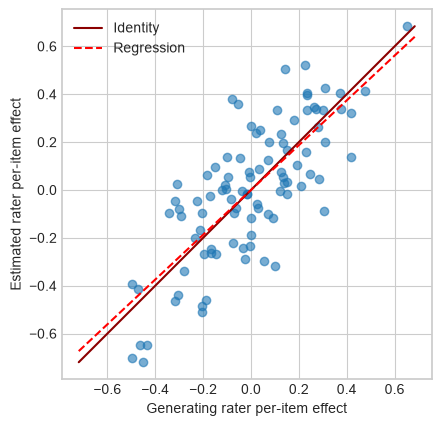

rater per-item effect Pearson correlation:              0.768
rater per-item effect SD ratio (estimated / generating): 1.219
rater per-item effect regression coefficient:            0.936
rater per-item effect RMSE:                              0.185


In [20]:
orig_item_effects = mfrm.generating.item_effects.stack()
est_item_effects = mfrm.raters_bivector_items.stack()
recovery_plot(orig_item_effects, est_item_effects, 'rater per-item effect', 'my_mfrm_bivector_rater_item_recovery.png')

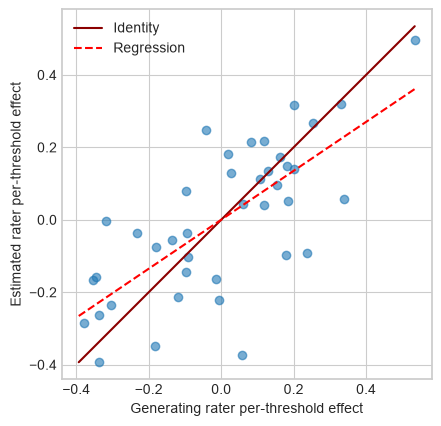

rater per-threshold effect Pearson correlation:              0.718
rater per-threshold effect SD ratio (estimated / generating): 0.941
rater per-threshold effect regression coefficient:            0.676
rater per-threshold effect RMSE:                              0.161


In [21]:
orig_threshold_effects = mfrm.generating.threshold_effects.stack()
est_threshold_effects = mfrm.raters_bivector_thresholds.stack()
recovery_plot(orig_threshold_effects, est_threshold_effects, 'rater per-threshold effect', 'my_mfrm_bivector_rater_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [22]:
%%time
mfrm.person_stats_df_bivector(full=True)
mfrm.person_stats_bivector.to_csv('mfrm_bivector_person_stats.csv')

CPU times: user 19.6 ms, sys: 888 μs, total: 20.5 ms
Wall time: 20.4 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [23]:
mfrm.person_stats_bivector.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.920,0.170,0.157,294,480,0.612,0.860,0.849,-0.761,-0.805
Person_2,-0.713,0.136,0.142,223,480,0.465,1.090,1.082,0.691,0.578
Person_3,-3.053,0.153,0.144,96,480,0.200,0.882,0.896,-0.738,-0.652
Person_4,-0.182,0.146,0.151,250,480,0.521,1.072,1.051,0.519,0.350
Person_5,0.777,0.168,0.167,289,480,0.602,0.995,0.999,0.033,0.058
Person_6,-0.657,0.137,0.132,226,480,0.471,0.930,0.994,-0.481,0.012
Person_7,-0.466,0.140,0.148,236,480,0.492,1.115,1.107,0.832,0.700
Person_8,-0.982,0.133,0.136,208,480,0.433,1.050,1.014,0.418,0.148
Person_9,0.374,0.159,0.151,274,480,0.571,0.905,0.937,-0.520,-0.291
Person_10,-1.841,0.132,0.133,158,480,0.329,1.012,1.042,0.135,0.346


And the same recovery check for person locations, against `mfrm.generating.persons`:

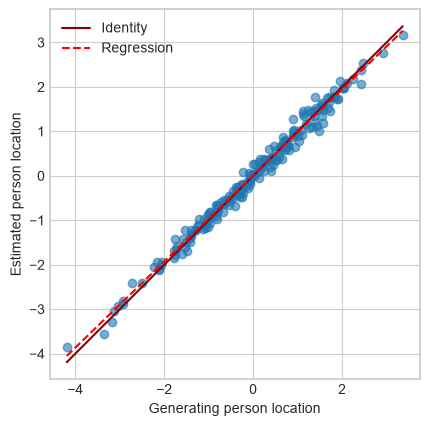

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 0.974
person location regression coefficient:            0.968
person location RMSE:                              0.15


In [24]:
recovery_plot(mfrm.generating.persons, mfrm.persons_bivector, 'person location', 'my_mfrm_bivector_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [25]:
%%time
mfrm.test_stats_df_bivector()
mfrm.test_stats_bivector.to_csv('mfrm_bivector_test_stats.csv')

CPU times: user 3.54 ms, sys: 631 μs, total: 4.17 ms
Wall time: 4.14 ms


Check the test statistics table

In [26]:
mfrm.test_stats_bivector

,Items,Persons
Mean,0.000,0.007
SD,0.744,1.296
Separation ratio,17.033,8.533
Strata,23.044,11.710
Reliability,0.997,0.986


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [27]:
%%time
mfrm.item_res_corr_analysis_bivector()
mfrm.item_residual_correlations_bivector.to_csv('mfrm_bivector_item_residual_correlations.csv')
mfrm.item_loadings_bivector.to_csv('mfrm_bivector_item_loadings.csv')

CPU times: user 7.96 ms, sys: 2.62 ms, total: 10.6 ms
Wall time: 14.9 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [28]:
round(mfrm.item_residual_correlations_bivector, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.022,-0.024,-0.013,0.029,-0.011,0.000,0.021,-0.002,-0.007,-0.035,-0.028
Item_2,-0.022,1.000,-0.000,-0.033,-0.014,-0.037,-0.014,-0.009,-0.011,-0.026,-0.001,0.035
Item_3,-0.024,-0.000,1.000,-0.022,-0.018,0.009,-0.049,0.012,-0.035,-0.011,-0.003,0.059
Item_4,-0.013,-0.033,-0.022,1.000,-0.012,-0.026,-0.023,0.002,0.008,-0.048,0.024,-0.004
Item_5,0.029,-0.014,-0.018,-0.012,1.000,-0.060,-0.024,-0.010,-0.026,0.010,-0.037,-0.020
Item_6,-0.011,-0.037,0.009,-0.026,-0.060,1.000,0.013,-0.002,-0.015,-0.014,-0.037,-0.010
Item_7,0.000,-0.014,-0.049,-0.023,-0.024,0.013,1.000,-0.021,-0.015,-0.007,-0.039,-0.001
Item_8,0.021,-0.009,0.012,0.002,-0.010,-0.002,-0.021,1.000,-0.033,0.013,-0.016,-0.067
Item_9,-0.002,-0.011,-0.035,0.008,-0.026,-0.015,-0.015,-0.033,1.000,-0.003,0.005,-0.044
Item_10,-0.007,-0.026,-0.011,-0.048,0.010,-0.014,-0.007,0.013,-0.003,1.000,-0.017,-0.018


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [29]:
round(mfrm.item_loadings_bivector['PC 1'], 3)

Item_1    -0.115
Item_2     0.104
Item_3     0.150
Item_4    -0.029
Item_5    -0.077
Item_6     0.028
Item_7    -0.021
Item_8    -0.095
Item_9    -0.081
Item_10   -0.061
Item_11   -0.005
Item_12    0.207
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [30]:
%%time
mfrm.rater_res_corr_analysis_bivector()
mfrm.rater_residual_correlations_bivector.to_csv('mfrm_bivector_rater_residual_correlations.csv')
mfrm.rater_loadings_bivector.to_csv('mfrm_bivector_rater_loadings.csv')

CPU times: user 13.4 ms, sys: 680 μs, total: 14.1 ms
Wall time: 14.1 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [31]:
round(mfrm.rater_residual_correlations_bivector, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,-0.026,0.003,-0.016,-0.019,0.005,0.014,-0.017
Rater_2,-0.026,1.000,0.002,0.018,-0.024,-0.042,-0.033,0.002
Rater_3,0.003,0.002,1.000,0.001,-0.024,-0.017,-0.051,-0.015
Rater_4,-0.016,0.018,0.001,1.000,-0.018,-0.015,-0.008,0.011
Rater_5,-0.019,-0.024,-0.024,-0.018,1.000,-0.044,-0.027,-0.027
Rater_6,0.005,-0.042,-0.017,-0.015,-0.044,1.000,-0.011,-0.021
Rater_7,0.014,-0.033,-0.051,-0.008,-0.027,-0.011,1.000,-0.024
Rater_8,-0.017,0.002,-0.015,0.011,-0.027,-0.021,-0.024,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [32]:
mfrm.rater_loadings_bivector['PC 1']

Rater_1   -0.188330
Rater_2    0.211629
Rater_3    0.078738
Rater_4    0.138887
Rater_5    0.012211
Rater_6   -0.135252
Rater_7   -0.189091
Rater_8    0.074386
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

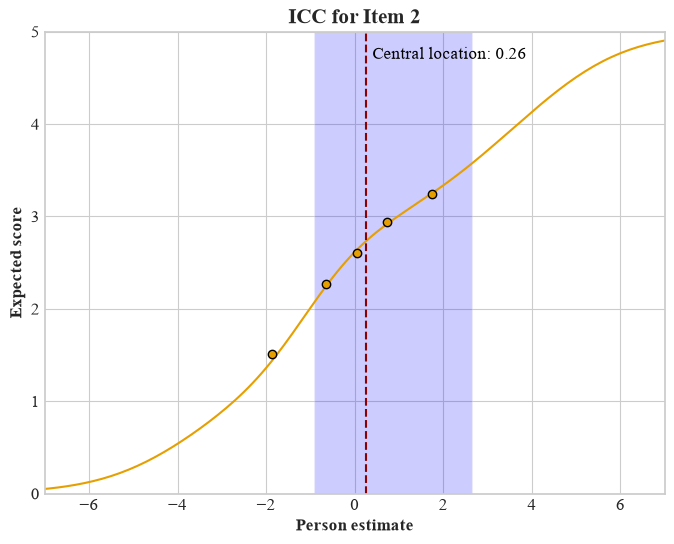

In [33]:
mfrm.icc_bivector('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_bivector_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

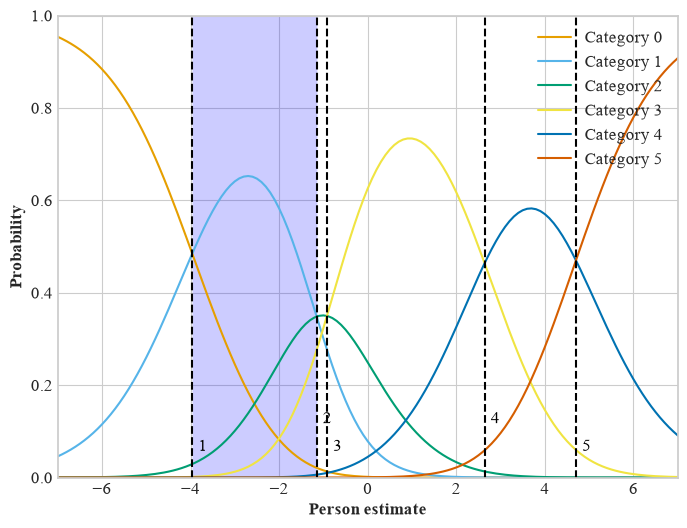

In [34]:
mfrm.crcs_bivector('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bivector_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

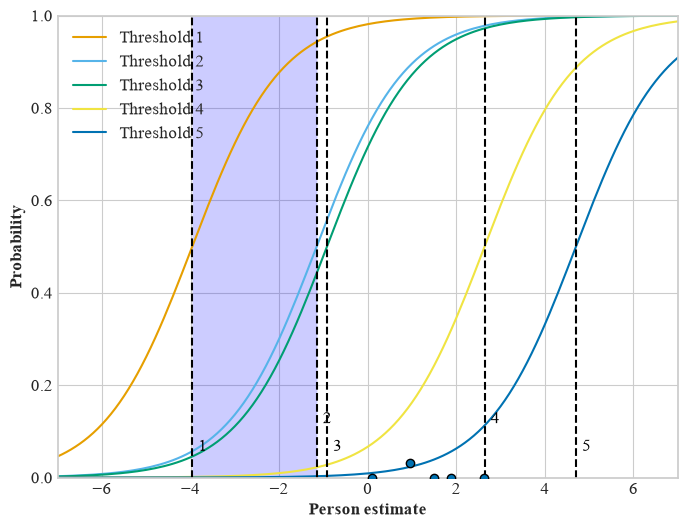

In [35]:
mfrm.threshold_ccs_bivector('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bivector_threshold_ccs')

Produce an item information function curve for Item 2

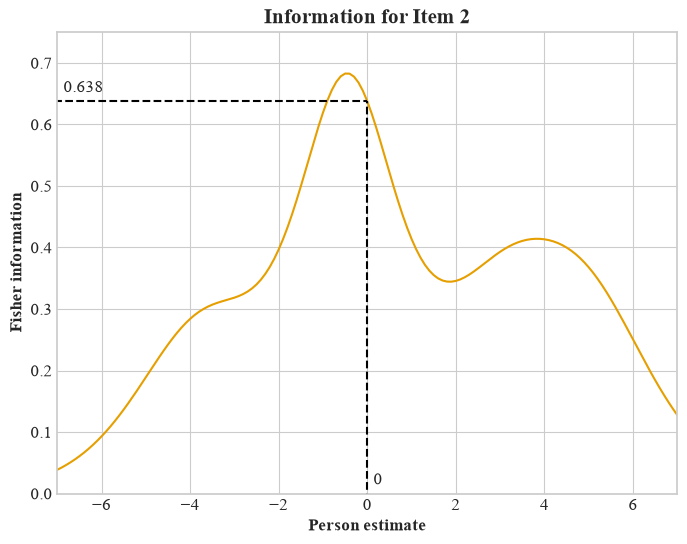

In [36]:
mfrm.iic_bivector('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2',
                  xmin=-7, xmax=7, filename='my_mfrm_bivector_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

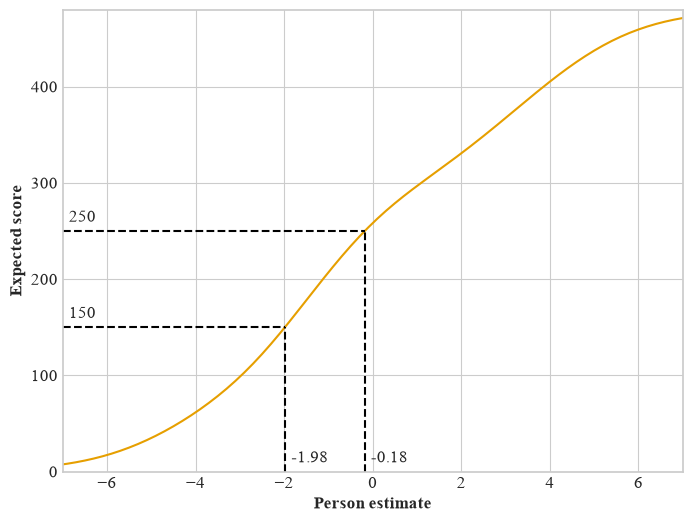

In [37]:
mfrm.tcc_bivector(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bivector_tcc')

Produce a test information curve

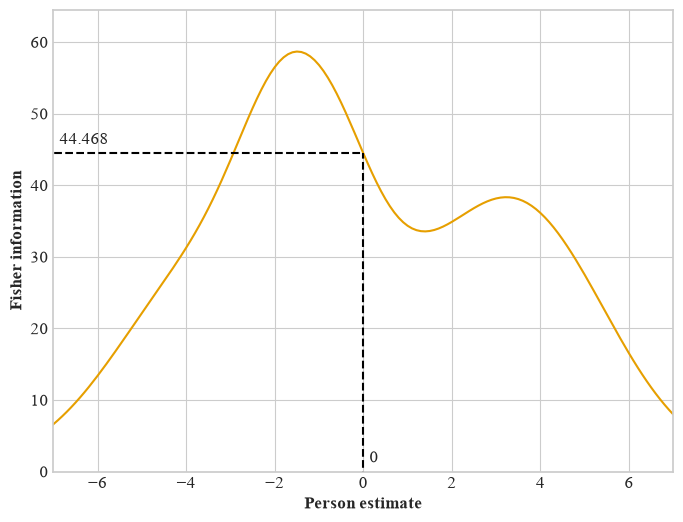

In [38]:
mfrm.test_info_bivector(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bivector_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

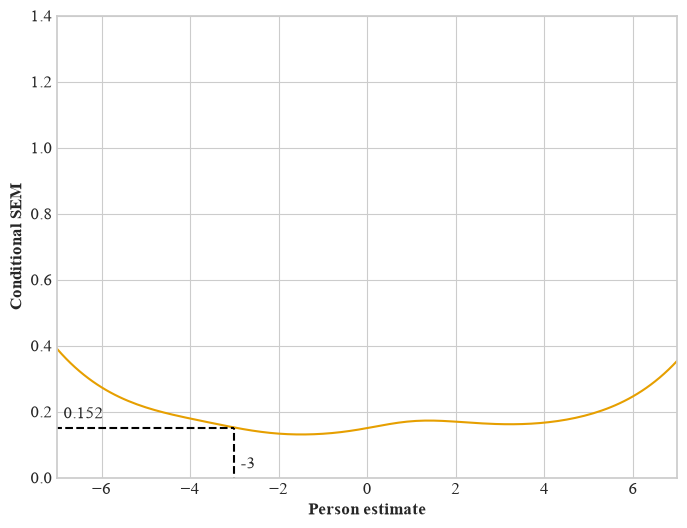

In [39]:
mfrm.test_csem_bivector(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_bivector_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

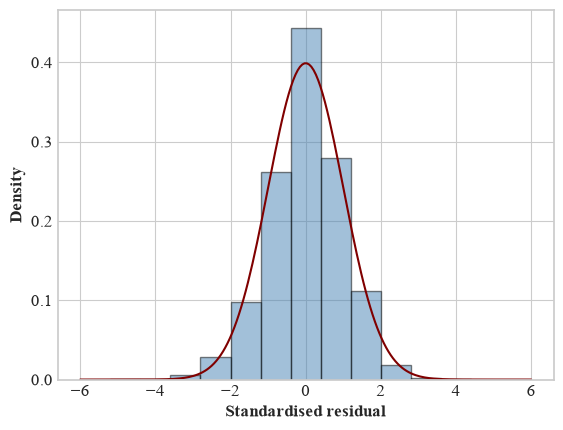

In [40]:
mfrm.std_residuals_plot_bivector(bin_width=0.6, normal=True, filename='my_mfrm_bivector_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [41]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_bivector_anchor(anchors)

CPU times: user 13.7 ms, sys: 661 μs, total: 14.3 ms
Wall time: 14.1 ms


Check the anchored item locations against the unanchored ones.

In [42]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_bivector})
round(item_check, 3)

,Unanchored,Anchored
Item_1,1.033,1.133
Item_2,0.261,0.323
Item_3,-0.499,-0.608
Item_4,0.753,0.645
Item_5,0.867,0.833
Item_6,-0.071,0.080
Item_7,-0.211,-0.192
Item_8,-1.039,-1.008
Item_9,-0.806,-0.847
Item_10,-0.225,-0.340


Check the anchored thresholds against the unanchored thresholds

In [43]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                                'Anchored': mfrm.anchor_thresholds_bivector})
round(threshold_check, 3)

,Unanchored,Anchored
1,-4.223,-4.100
2,-1.415,-1.407
3,-1.181,-1.182
4,2.378,2.303
5,4.441,4.386


Check the anchored per-item rater effects against the unanchored ones - two dataframes

In [44]:
round(mfrm.raters_bivector_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.413,0.427,-0.018,0.348,0.127,0.197,0.133,-0.317,0.269,-0.074,0.202,0.200
Rater_2,0.138,-0.058,-0.098,-0.394,-0.119,0.407,0.045,0.136,0.016,-0.095,-0.202,0.263
Rater_3,-0.039,0.075,0.027,-0.287,-0.046,-0.090,-0.004,0.056,-0.018,0.407,0.334,-0.241
Rater_4,0.322,0.239,0.086,0.333,0.338,0.523,0.339,0.684,0.001,-0.266,0.158,0.332
Rater_5,-0.412,-0.189,-0.169,-0.268,-0.220,-0.647,-0.703,-0.047,0.075,0.505,0.379,0.055
Rater_6,0.097,0.165,-0.006,0.035,-0.102,-0.486,-0.108,-0.074,-0.646,-0.299,-0.463,-0.339
Rater_7,-0.438,-0.720,-0.116,-0.016,0.002,0.361,-0.097,-0.462,0.235,-0.233,-0.512,-0.025
Rater_8,-0.080,0.061,0.294,0.249,0.020,-0.265,0.396,0.024,0.069,0.054,0.103,-0.245


In [45]:
round(mfrm.anchor_raters_bivector_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.204,0.257,-0.017,0.348,0.052,-0.062,0.005,-0.457,0.202,-0.067,0.079,0.062
Rater_2,-0.071,-0.229,-0.097,-0.394,-0.194,0.148,-0.083,-0.003,-0.051,-0.088,-0.325,0.124
Rater_3,-0.247,-0.096,0.028,-0.287,-0.121,-0.349,-0.133,-0.084,-0.085,0.414,0.211,-0.379
Rater_4,0.114,0.068,0.087,0.333,0.263,0.264,0.211,0.544,-0.066,-0.259,0.035,0.193
Rater_5,-0.621,-0.360,-0.169,-0.268,-0.295,-0.907,-0.831,-0.187,0.008,0.512,0.256,-0.084
Rater_6,-0.112,-0.006,-0.005,0.035,-0.177,-0.746,-0.236,-0.213,-0.713,-0.292,-0.586,-0.477
Rater_7,-0.646,-0.890,-0.116,-0.016,-0.073,0.101,-0.225,-0.601,0.168,-0.226,-0.635,-0.164
Rater_8,-0.289,-0.110,0.294,0.249,-0.055,-0.525,0.267,-0.115,0.002,0.061,-0.020,-0.384


Check the anchored per-threshold rater effects against the unanchored ones - two dataframes

In [46]:
round(mfrm.raters_bivector_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.286,0.053,0.266,-0.074,0.040
Rater_2,0.247,0.172,-0.264,-0.214,0.058
Rater_3,0.317,-0.159,-0.102,0.043,-0.098
Rater_4,0.216,-0.035,0.097,-0.057,-0.221
Rater_5,-0.167,-0.164,0.497,-0.348,0.181
Rater_6,-0.374,0.130,0.135,0.112,-0.003
Rater_7,-0.093,0.147,-0.236,0.218,-0.038
Rater_8,0.139,-0.144,-0.393,0.319,0.079


In [47]:
round(mfrm.anchor_raters_bivector_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.409,0.045,0.267,0.001,0.095
Rater_2,0.124,0.165,-0.263,-0.138,0.113
Rater_3,0.193,-0.167,-0.102,0.118,-0.043
Rater_4,0.092,-0.043,0.098,0.019,-0.166
Rater_5,-0.290,-0.172,0.498,-0.272,0.236
Rater_6,-0.497,0.123,0.135,0.188,0.052
Rater_7,-0.216,0.140,-0.235,0.294,0.017
Rater_8,0.016,-0.152,-0.393,0.394,0.134
